In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 🔎 **1.Comprensione del dataset**


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv']


In [27]:
path = "/content/drive/MyDrive/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv"
df = pd.read_csv(path)

df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [28]:
print("Le colonne del dataframe sono:", df.columns.tolist())
print("\n Statistiche descrittive:\n", df.describe())
print("\n La forma del dataframe (righe, colonne) è:", df.shape)
print("\n Numero di valori unici per colonna:\n", df.nunique())
#print("\n Numero di transazioni duplicate:", df.duplicated(subset="transaction_id").sum())
print("\n Numero di valori nulli per colonna:\n", df.isnull().sum())
print("\n Tipi di dati delle colonne:\n", df.dtypes)

Le colonne del dataframe sono: ['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']

 Statistiche descrittive:
                age  daily_screen_time_hours  social_media_hours  gaming_hours  \
count  7500.000000              7500.000000         7500.000000   7500.000000   
mean     26.568800                 7.499912            3.273484      2.014183   
std       5.197108                 2.609188            1.585342      1.146039   
min      18.000000                 3.000000            0.500000      0.000000   
25%      22.000000                 5.220000            1.910000      1.020000   
50%      27.000000                 7.525000            3.270000      2.040000   
75%      31.000000                 9.810000            4.630000      2.990000   


In [29]:
df=df.drop_duplicates()
df = df.dropna()

In [30]:
df.columns = df.columns.str.lower()

In [31]:
# Rimozione valori non realistici
df = df[(df["age"] > 10) & (df["age"] < 100)]
df = df[(df["daily_screen_time_hours"] >= 0) & (df["daily_screen_time_hours"] <= 24)]

# 🔍**2.Analisi demografica**
L’età influisce sull’uso dello schermo?

Esistono differenze significative tra i generi?

/tmp/ipykernel_354/3329583017.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_screen = df.groupby('age_group')['daily_screen_time_hours'].mean()


age_group
18-25    7.840016
25-30    7.886148
30-35    7.910792
Name: daily_screen_time_hours, dtype: float64


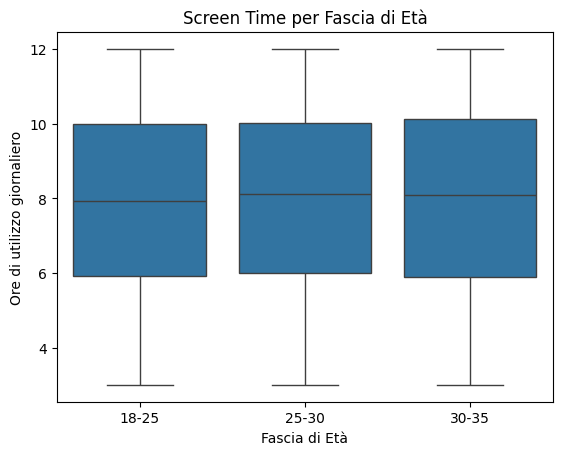

In [32]:
bins = [18, 25, 30, 35]
labels = ["18-25", "25-30", "30-35"]

# Creazione variabile age_group
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Media screen time per fascia
age_screen = df.groupby('age_group')['daily_screen_time_hours'].mean()
print(age_screen)

# Boxplot
sns.boxplot(x='age_group', y='daily_screen_time_hours', data=df)
plt.title('Screen Time per Fascia di Età')
plt.xlabel('Fascia di Età')
plt.ylabel('Ore di utilizzo giornaliero')
plt.show()

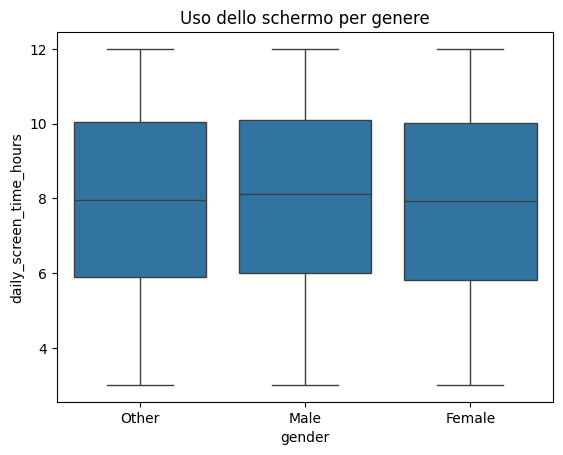

In [33]:
plt.figure()
sns.boxplot(data=df, x="gender", y="daily_screen_time_hours")
plt.title("Uso dello schermo per genere")
plt.show()

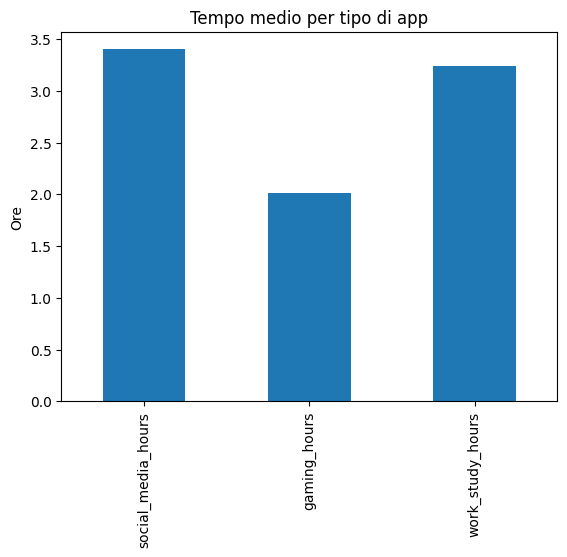

In [34]:
usage_cols = [
 'social_media_hours',
'gaming_hours',
'work_study_hours'
]

df[usage_cols].mean().plot(kind="bar")
plt.title("Tempo medio per tipo di app")
plt.ylabel("Ore")
plt.show()

        social_media_hours  gaming_hours  work_study_hours
gender                                                    
Female            3.393601      2.022781          3.274613
Male              3.423516      2.015893          3.199610
Other             3.382322      2.006938          3.248509


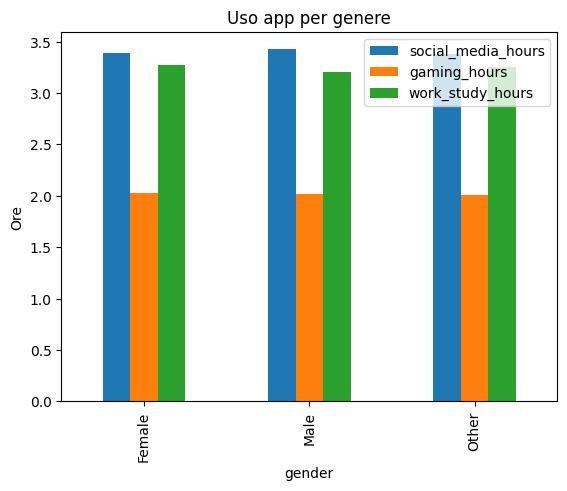

In [35]:
gender_usage = df.groupby("gender")[usage_cols].mean()
print(gender_usage)

gender_usage.plot(kind="bar")
plt.title("Uso app per genere")
plt.ylabel("Ore")
plt.show()

In [36]:
df.groupby('age_group')['daily_screen_time_hours'].mean()

/tmp/ipykernel_354/3232690239.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['daily_screen_time_hours'].mean()


,daily_screen_time_hours
age_group,
18-25,7.840016
25-30,7.886148
30-35,7.910792


In [37]:
df.groupby('gender')['daily_screen_time_hours'].mean()

,daily_screen_time_hours
gender,
Female,7.820399
Male,7.915972
Other,7.855976


In [38]:
df.groupby('gender')[usage_cols].mean()

,social_media_hours,gaming_hours,work_study_hours
gender,,,
Female,3.393601,2.022781,3.274613
Male,3.423516,2.015893,3.199610
Other,3.382322,2.006938,3.248509


# **📱3.Uso dello schermo (Core Analysis)**

Quanto tempo medio viene speso al giorno sullo schermo?

Come si distribuisce tra:
*   social media
*   gaming
*   lavoro/studio

In [51]:
media_screen_time = df['daily_screen_time_hours'].mean()
print(f"Tempo medio giornaliero: {media_screen_time:.2f} ore")

median_screen_time = df['daily_screen_time_hours'].median()
print(f"Tempo medio giornaliero: {median_screen_time:.2f} ore")

Tempo medio giornaliero: 7.86 ore
Tempo medio giornaliero: 8.01 ore


In [40]:
activity_means = df[usage_cols].mean()
print(activity_means)

social_media_hours    3.400090
gaming_hours          2.015176
work_study_hours      3.240322
dtype: float64


# **😴 4. Sonno e benessere**

Il sonno è correlato con stress o dipendenza?

Dormire meno aumenta il rischio di dipendenza?

In [41]:
print(df['addiction_level'])

2           Mild
3       Moderate
4         Severe
5         Severe
6         Severe
          ...   
7494      Severe
7495    Moderate
7497      Severe
7498      Severe
7499      Severe
Name: addiction_level, Length: 6681, dtype: object


In [42]:
df["addiction_level_num"] = df["addiction_level"].map({
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3
})

In [43]:
df["stress_level_num"] = df["stress_level"].map({
    "Low": 1,
    "Medium": 2,
    "High": 3
})

In [44]:
print(df[["stress_level", "stress_level_num"]].head())

  stress_level  stress_level_num
2         High                 3
3         High                 3
4          Low                 1
5       Medium                 2
6       Medium                 2


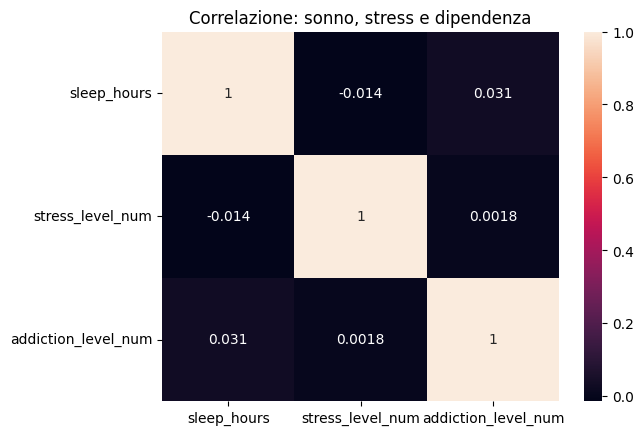

In [45]:
corr = df[["sleep_hours", "stress_level_num", "addiction_level_num"]].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlazione: sonno, stress e dipendenza")
plt.show()

# **🔔5. Notifiche e comportamento digitale**
Più notifiche portano a maggiore utilizzo?

Il numero di aperture delle app influisce sulla dipendenza?

In [55]:
cols = [
    "notifications_per_day",
    "app_opens_per_day",
    "daily_screen_time_hours"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=cols)

print(df['notifications_per_day'])

2        44
3       178
4       136
5        82
6       165
       ... 
7494     78
7495    249
7497    207
7498    134
7499    215
Name: notifications_per_day, Length: 6681, dtype: int64


In [56]:
corr = df["notifications_per_day"].corr(df["daily_screen_time_hours"])
print(f"Correlazione notifiche-uso: {corr:.2f}")

Correlazione notifiche-uso: 0.00


/tmp/ipykernel_354/4214991602.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  notif_analysis = df.groupby("notif_group")["daily_screen_time_hours"].mean()


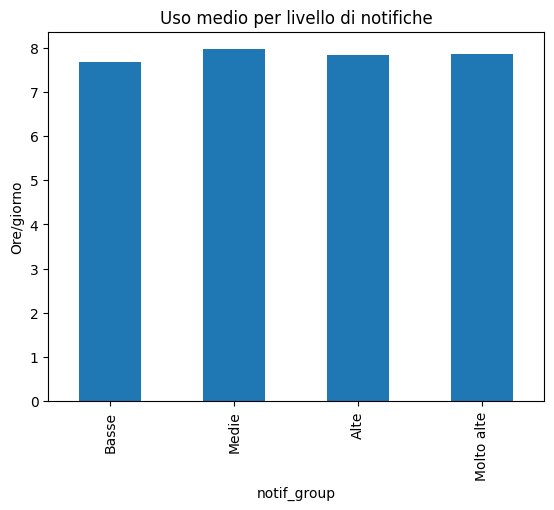

In [48]:
bins = [0, 20, 50, 100, 300]
labels = ["Basse", "Medie", "Alte", "Molto alte"]

df["notif_group"] = pd.cut(df["notifications_per_day"], bins=bins, labels=labels)

notif_analysis = df.groupby("notif_group")["daily_screen_time_hours"].mean()

notif_analysis.plot(kind="bar")
plt.title("Uso medio per livello di notifiche")
plt.ylabel("Ore/giorno")
plt.show()

In [57]:
corr = df["app_opens_per_day"].corr(df["addiction_level_num"])
print(f"Correlazione aperture app: {corr:.2f}")

Correlazione aperture app: 0.01


# **🎓 6. Impatto su studio/lavoro**
Lo screen time influisce su academic_work_impact?

La dipendenza peggiora le performance?

In [61]:
print(df['academic_work_impact'].unique())

['No' 'Yes']


In [62]:
df['academic_work_impact_num'] = df['academic_work_impact'].map({
    'No': 0,
    'Yes': 1
})

In [63]:
corr = df['daily_screen_time_hours'].corr(df['academic_work_impact_num'])
print("Correlazione screen time vs impatto:", corr)

Correlazione screen time vs impatto: -0.002457187404331025


In [64]:
df.groupby('academic_work_impact')['daily_screen_time_hours'].mean()

,daily_screen_time_hours
academic_work_impact,
No,7.871034
Yes,7.858669


# **😰 7. Stress e dipendenza**
Stress e addiction sono correlati?

Le persone più stressate usano di più lo smartphone?

# ⚠️**8. Analisi della dipendenza (addicted_label)**

Quali variabili distinguono maggiormente i due gruppi?

Esistono soglie critiche?

In [65]:
corr_stress_addiction = df['stress_level_num'].corr(df['addiction_level_num'])
print("Correlazione stress vs dipendenza:", corr_stress_addiction)

Correlazione stress vs dipendenza: 0.0017991581756249746


In [66]:
mean_addiction_by_stress = df.groupby('stress_level_num')['addiction_level_num'].mean()
print(mean_addiction_by_stress)

stress_level_num
1    2.156167
2    2.160946
3    2.159401
Name: addiction_level_num, dtype: float64


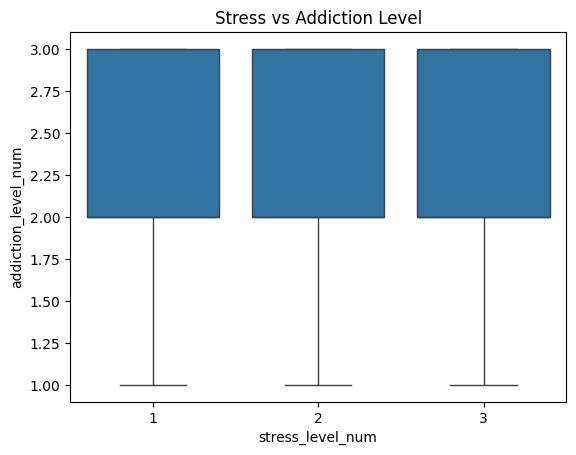

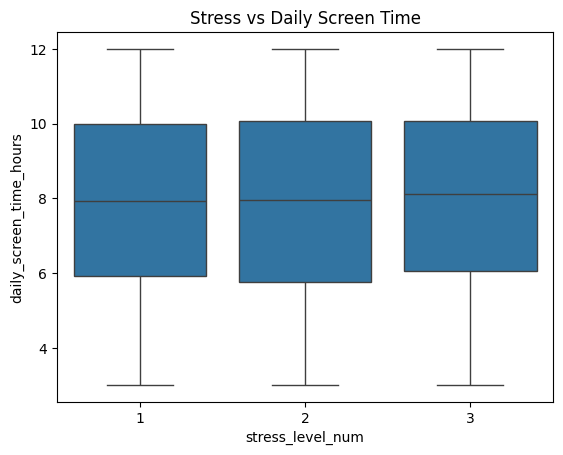

In [68]:
sns.boxplot(x='stress_level_num', y='addiction_level_num', data=df)
plt.title("Stress vs Addiction Level")
plt.show()

# Stress vs screen time
sns.boxplot(x='stress_level_num', y='daily_screen_time_hours', data=df)
plt.title("Stress vs Daily Screen Time")
plt.show()